# Imbalanced-Aware Binary Toxicity Classification

**Design principles**:
- All parameters in `CONFIG` — nothing hardcoded elsewhere
- `ImbPipeline` keeps oversampling inside each CV fold (no leakage)
- Train + Val combined — 5-fold stratified CV replaces a fixed validation split
- OOF predicted probabilities used for threshold tuning (no held-out slice wasted)

**Stages**:
1. Oversampling comparison — ROS, SMOTE, BorderlineSMOTE, ADASYN via 5-fold CV
2. Model comparison — LogisticRegressionCV, ComplementNB, LinearSVC (Optuna TPE)
3. Final evaluation — single run on held-out test set
4. Interpretability — feature weights, error analysis

In [1]:
import sys, warnings, time
sys.path.insert(0, '../models')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, average_precision_score,
    roc_curve, precision_recall_curve,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

from baseline import _feature_union, ALL_STOPWORDS, RANDOM_STATE
from preprocessing import preprocess_df

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

CONFIG = {
    'paths': {
        'train':       '../data/train_cleaned.parquet',
        'test':        '../data/test_cleaned.parquet',
        'test_labels': '../data/test_labels_cleaned.parquet',
    },
    'cv': {
        'n_splits': 5,
        'scoring':  'f1_macro',
    },
    'optuna': {
        'n_trials': 30,
    },
    'max_features_smote': 10_000,
    'random_state': RANDOM_STATE,
}

## 1. Load & Prepare Data

In [2]:
train_raw   = pd.read_parquet(CONFIG['paths']['train'])
test_raw    = pd.read_parquet(CONFIG['paths']['test'])
test_labels = pd.read_parquet(CONFIG['paths']['test_labels'])

# Binary target: 1 if any toxicity label is set
train_raw['is_toxic'] = (train_raw[LABELS].sum(axis=1) > 0).astype(int)

# Test set: drop withheld (-1) rows, then collapse labels
evaluable = test_labels[test_labels['toxic'] != -1].copy()
evaluable['is_toxic'] = (evaluable[LABELS].sum(axis=1) > 0).astype(int)
eval_df = evaluable.merge(test_raw[['id', 'comment_text']], on='id')

print(f"Train : {len(train_raw):,} rows  |  toxic {train_raw['is_toxic'].mean()*100:.1f}%")
print(f"Test  : {len(eval_df):,} rows   |  toxic {eval_df['is_toxic'].sum():,} ({eval_df['is_toxic'].mean()*100:.1f}%")

Train : 158,325 rows  |  toxic 10.1%
Test  : 61,845 rows   |  toxic 6,164 (10.0%


## 2. Preprocess & Extract Features

Features are precomputed on the full training set before CV.  
This introduces minor TF-IDF vocabulary leakage from val folds (known trade-off for speed).  
The oversampler inside `ImbPipeline` is still applied only within each training fold — no leakage there.

In [3]:
print('Preprocessing text...')
train_text = preprocess_df(train_raw['comment_text'])
test_text  = preprocess_df(eval_df['comment_text_x'])

y_train = train_raw['is_toxic'].values
y_test  = eval_df['is_toxic'].values

# Word TF-IDF only (no char n-grams) — drops ~20k features, speeds up all downstream cells.
# norm='l2': row-normalises so dot product = cosine similarity.
# max_df=0.95: drops near-universal terms that carry no discriminative signal.
print('Extracting features...')
_word_tfidf = TfidfVectorizer(
    sublinear_tf=True, max_features=100_000, ngram_range=(1, 2),
    min_df=3, max_df=0.95, norm='l2', analyzer='word', stop_words=ALL_STOPWORDS,
)
X_train_raw = _word_tfidf.fit_transform(train_text)
X_test_raw  = _word_tfidf.transform(test_text)

scaler  = MaxAbsScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Keep feat_union fitted for interpretability cell feature name reconstruction.
feat_union = _feature_union()
feat_union.fit(train_text)

# Word TF-IDF only (no scaling) — used for ComplementNB.
nb_tfidf = TfidfVectorizer(
    sublinear_tf=True, max_features=100_000, ngram_range=(1, 2),
    min_df=3, max_df=0.95, norm='l2', analyzer='word', stop_words=ALL_STOPWORDS,
)
X_train_nb = nb_tfidf.fit_transform(train_text)
X_test_nb  = nb_tfidf.transform(test_text)

print(f'X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}')

Preprocessing text...
Extracting features...
X_train shape: (158325, 100000)  |  X_test shape: (61845, 100000)


In [4]:
smote_tfidf = TfidfVectorizer(
    sublinear_tf=True,
    max_features=CONFIG['max_features_smote'],
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    norm='l2',
    analyzer='word',
    stop_words=ALL_STOPWORDS,
)
_smote_scaler = MaxAbsScaler()
X_train_smote = _smote_scaler.fit_transform(smote_tfidf.fit_transform(train_text))
print(f'X_train_smote shape (for oversampling comparison): {X_train_smote.shape}')

X_train_smote shape (for oversampling comparison): (158325, 10000)


## 3. TF-IDF Ablation — Word Only vs Word + Char

Does adding character n-grams on top of word TF-IDF actually improve performance?  
Char n-grams catch obfuscated toxic words (`f*ck`, `a$$`, `b1tch`) but add ~20k features and extra compute.

Run this before the oversampling comparison to decide whether the char TF-IDF is worth keeping.

In [5]:
rs  = CONFIG['random_state']
skf = StratifiedKFold(n_splits=CONFIG['cv']['n_splits'], shuffle=True, random_state=rs)

# Word-only TF-IDF: same vocabulary settings as the full pipeline, no char n-grams
_tfidf_word_only = TfidfVectorizer(
    sublinear_tf=True, max_features=100_000, ngram_range=(1, 2),
    min_df=3, max_df=0.95, norm='l2', analyzer='word', stop_words=ALL_STOPWORDS,
)
X_train_word_only = MaxAbsScaler().fit_transform(
    _tfidf_word_only.fit_transform(train_text)
)
X_test_word_only = MaxAbsScaler().fit_transform(
    _tfidf_word_only.transform(test_text)
)

# Word + Char TF-IDF + length: the full X_train already computed in Section 2
# X_train shape: word (100k) + char (20k) + length (2) = ~120k features

ref_lr = LogisticRegression(class_weight='balanced', C=1.0, solver='liblinear',
                             max_iter=1000, random_state=rs)

feat_configs = {
    'Word TF-IDF only (~100k)':          X_train_word_only,
    'Word + Char TF-IDF + length (~120k)': X_train,
}

feat_scores = {}
rows = []
for name, X_abl in feat_configs.items():
    t0 = time.time()
    scores = cross_val_score(Pipeline([('clf', ref_lr)]), X_abl, y_train,
                             cv=skf, scoring='f1_macro', n_jobs=-1)
    elapsed = time.time() - t0
    feat_scores[name] = scores
    rows.append({'Feature set': name,
                 'CV Macro F1': round(scores.mean(), 4),
                 'Std': round(scores.std(), 4),
                 'Time (s)': round(elapsed, 1)})
    print(f'{name:<45} macro F1: {scores.mean():.4f} ± {scores.std():.4f}  ({elapsed:.1f}s)')

abl_df = pd.DataFrame(rows).sort_values('CV Macro F1', ascending=False).reset_index(drop=True)
print()
print(abl_df.to_string(index=False))

best_feat_name = abl_df.iloc[0]['Feature set']
print(f'\n→ Best feature set: {best_feat_name}')
print('If word-only matches word+char, drop char TF-IDF to halve feature size and speed up training.')

Word TF-IDF only (~100k)                      macro F1: 0.8820 ± 0.0020  (3.3s)
Word + Char TF-IDF + length (~120k)           macro F1: 0.8820 ± 0.0020  (2.7s)

                        Feature set  CV Macro F1   Std  Time (s)
           Word TF-IDF only (~100k)        0.882 0.002       3.3
Word + Char TF-IDF + length (~120k)        0.882 0.002       2.7

→ Best feature set: Word TF-IDF only (~100k)
If word-only matches word+char, drop char TF-IDF to halve feature size and speed up training.


## 3. Oversampling Comparison

5-fold stratified CV with a reference LogisticRegression to isolate the effect of each sampler.

In [6]:
rs = CONFIG['random_state']
skf = StratifiedKFold(n_splits=CONFIG['cv']['n_splits'], shuffle=True, random_state=rs)
ref_lr = LogisticRegression(class_weight='balanced', C=1.0, solver='liblinear', random_state=rs, max_iter=1000)

samplers = {
    'None (class_weight)': None,
    'RandomOverSampler':   RandomOverSampler(random_state=rs),
    'SMOTE':               SMOTE(random_state=rs),
    'BorderlineSMOTE':     BorderlineSMOTE(random_state=rs),
    'ADASYN':              ADASYN(random_state=rs),
}

# Uses X_train_smote (10k dims) — same sampler ranking transfers to the full model.
sampler_scores = {}
for name, sampler in samplers.items():
    pipe = (
        ImbPipeline([('sampler', sampler), ('clf', ref_lr)])
        if sampler is not None
        else Pipeline([('clf', ref_lr)])
    )
    scores = cross_val_score(pipe, X_train_smote, y_train, cv=skf,
                             scoring=CONFIG['cv']['scoring'], n_jobs=-1)
    sampler_scores[name] = scores
    print(f'{name:<25} macro F1: {scores.mean():.4f} ± {scores.std():.4f}')

best_sampler_name = max(sampler_scores, key=lambda k: sampler_scores[k].mean())
best_sampler      = samplers[best_sampler_name]
print(f'\n→ Best sampler: {best_sampler_name}')

None (class_weight)       macro F1: 0.8525 ± 0.0008
RandomOverSampler         macro F1: 0.8524 ± 0.0001
SMOTE                     macro F1: 0.8109 ± 0.0033
BorderlineSMOTE           macro F1: 0.8073 ± 0.0037
ADASYN                    macro F1: 0.7962 ± 0.0034

→ Best sampler: None (class_weight)


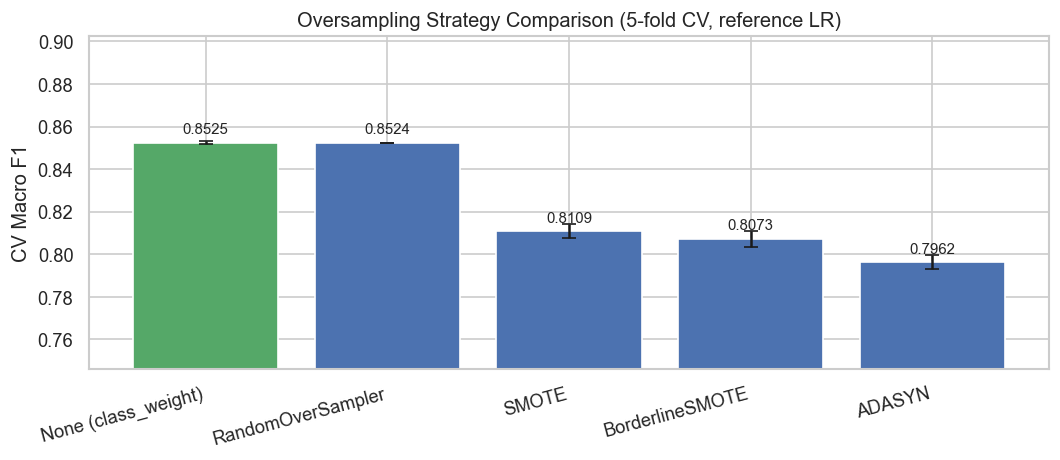

In [7]:
means = [sampler_scores[k].mean() for k in samplers]
stds  = [sampler_scores[k].std()  for k in samplers]
colors = ['#55a868' if k == best_sampler_name else '#4c72b0' for k in samplers]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(samplers.keys()), means, yerr=stds, capsize=4,
              color=colors, error_kw={'elinewidth': 1.5})
ax.set_ylabel('CV Macro F1')
ax.set_title('Oversampling Strategy Comparison (5-fold CV, reference LR)')
ax.set_ylim(min(means) - 0.05, max(means) + 0.05)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 4. Model Comparison (with best sampler)

Each model is evaluated via 5-fold CV. Best C is selected automatically.

In [8]:
# n_jobs=1 on LogisticRegressionCV — the outer cross_validate already uses n_jobs=-1.
# Nesting both at -1 causes fork/BLAS deadlocks on macOS.
lr_cv = LogisticRegressionCV(
    Cs=10, cv=skf, scoring='f1_macro',
    class_weight='balanced', solver='liblinear',
    max_iter=1000, random_state=rs, n_jobs=1,
)
pipe_lr = (
    ImbPipeline([('sampler', best_sampler), ('clf', lr_cv)])
    if best_sampler is not None
    else Pipeline([('clf', lr_cv)])
)
t0 = time.time()
lr_results = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                             scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
scores_lr = lr_results['test_f1_macro']
print(f'LogisticRegressionCV  macro F1: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}  ({time.time()-t0:.1f}s)')

LogisticRegressionCV  macro F1: 0.8850 ± 0.0014  (190.6s)


In [9]:
# Base pipe — clone() inside the objective copies it without mutating the original.
base_nb_pipe = (
    ImbPipeline([('sampler', best_sampler), ('clf', ComplementNB())])
    if best_sampler is not None
    else Pipeline([('clf', ComplementNB())])
)

def nb_objective(trial):
    alpha = trial.suggest_float('alpha', 0.001, 2.0, log=True)
    pipe  = clone(base_nb_pipe)
    pipe.set_params(clf__alpha=alpha)
    return cross_val_score(pipe, X_train_nb, y_train, cv=skf,
                           scoring=CONFIG['cv']['scoring'], n_jobs=-1).mean()

study_nb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=rs),
)
study_nb.optimize(nb_objective, n_trials=CONFIG['optuna']['n_trials'], show_progress_bar=True)
best_alpha = study_nb.best_params['alpha']
print(f'Best alpha: {best_alpha:.4f}')

# Re-evaluate tuned pipe for the comparison table
tuned_nb_pipe = clone(base_nb_pipe)
tuned_nb_pipe.set_params(clf__alpha=best_alpha)
t0 = time.time()
nb_results = cross_validate(tuned_nb_pipe, X_train_nb, y_train, cv=skf,
                             scoring=['f1_macro', 'f1_weighted', 'accuracy'], n_jobs=-1)
scores_nb = nb_results['test_f1_macro']
print(f'ComplementNB (α={best_alpha:.4f})  macro F1: {scores_nb.mean():.4f} ± {scores_nb.std():.4f}  ({time.time()-t0:.1f}s)')

Best trial: 11. Best value: 0.833831: 100%|██████████| 30/30 [00:09<00:00,  3.26it/s]


Best alpha: 1.2006
ComplementNB (α=1.2006)  macro F1: 0.8338 ± 0.0027  (0.2s)


In [10]:
# n_jobs=1 inside the objective — Optuna's trial loop is the outer parallel context.
# After this cell, print study_svc.best_params['C'] and hardcode it in future runs
# to skip the 30-trial search.
def svc_objective(trial):
    C       = trial.suggest_float('C', 1e-3, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    clf = LinearSVC(
        C=C, penalty=penalty, dual=(penalty == 'l2'),
        class_weight='balanced', max_iter=5000, random_state=rs,
    )
    pipe = (
        ImbPipeline([('sampler', best_sampler), ('clf', clf)])
        if best_sampler is not None
        else Pipeline([('clf', clf)])
    )
    return cross_val_score(pipe, X_train, y_train, cv=skf,
                           scoring=CONFIG['cv']['scoring'], n_jobs=1).mean()

study_svc = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=rs),
)
t0 = time.time()
study_svc.optimize(svc_objective, n_trials=CONFIG['optuna']['n_trials'], show_progress_bar=True)

best_svc_params = study_svc.best_params
scores_svc      = study_svc.best_value
print(f'LinearSVC (Optuna)    macro F1: {scores_svc:.4f}  params: {best_svc_params}  ({time.time()-t0:.1f}s)')
print(f'\n→ To skip Optuna next time, hardcode: C={best_svc_params["C"]:.4f}')

Best trial: 21. Best value: 0.88441: 100%|██████████| 30/30 [17:11<00:00, 34.37s/it] 

LinearSVC (Optuna)    macro F1: 0.8844  params: {'C': 0.7813882258601701, 'penalty': 'l1'}  (1031.2s)

→ To skip Optuna next time, hardcode: C=0.7814


In [11]:
import joblib
model_cv_scores = {
    'LogisticRegressionCV': scores_lr.mean(),
    'ComplementNB':         scores_nb.mean(),
    'LinearSVC (Optuna)':   scores_svc,
}
comparison = pd.DataFrame([
    {'Model': k, 'CV Macro F1': round(v, 4)}
    for k, v in model_cv_scores.items()
]).sort_values('CV Macro F1', ascending=False)
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]['Model']
print(f'\n→ Best model: {best_model_name}')

# save the best model the top three models to disk
for model_name in comparison['Model']:
    # fit the best models on the full training set (not just CV folds) before saving
    if model_name == 'LogisticRegressionCV':
        model = clone(pipe_lr).fit(X_train, y_train)
    elif model_name == 'ComplementNB':
        model = clone(tuned_nb_pipe).fit(X_train_nb, y_train)
    elif model_name == 'LinearSVC (Optuna)':
        clf = LinearSVC(
            C=study_svc.best_params['C'], penalty=study_svc.best_params['penalty'],
            dual=(study_svc.best_params['penalty'] == 'l2'),
            class_weight='balanced', max_iter=5000, random_state=rs,
        )
        model = (
            ImbPipeline([('sampler', best_sampler), ('clf', clf)])
            if best_sampler is not None
            else Pipeline([('clf', clf)])
        ).fit(X_train, y_train)
        
    # dump the fitted model to disk for later test evaluation and interpretability analysis
    joblib.dump(model, f'../../models/binary/social_media_{model_name.replace(" ", "_")}_model.joblib')
    print(f'{model_name} saved to ../../models/binary/social_media_{model_name.replace(" ", "_")}_model.joblib')
    
print(f'\nBest model fitted on full training set. Ready for test evaluation in the next cell.')

               Model  CV Macro F1
LogisticRegressionCV       0.8850
  LinearSVC (Optuna)       0.8844
        ComplementNB       0.8338

→ Best model: LogisticRegressionCV
LogisticRegressionCV saved to ../../models/binary/social_media_LogisticRegressionCV_model.joblib
LinearSVC (Optuna) saved to ../../models/binary/social_media_LinearSVC_(Optuna)_model.joblib
ComplementNB saved to ../../models/binary/social_media_ComplementNB_model.joblib

Best model fitted on full training set. Ready for test evaluation in the next cell.


## 5. Final Evaluation on Test Set

Best model is fit on the **full training set**.  
Decision threshold is tuned on out-of-fold predicted probabilities (no separate val slice needed).

In [12]:
# Build final model based on winner
if best_model_name == 'LogisticRegressionCV':
    final_clf = LogisticRegressionCV(
        Cs=10, cv=5, scoring='f1_macro',
        class_weight='balanced', solver='liblinear',
        max_iter=1000, random_state=rs,
    )
    X_fit, X_eval_final = X_train, X_test
elif best_model_name == 'ComplementNB':
    final_clf = ComplementNB()
    X_fit, X_eval_final = X_train_nb, X_test_nb
else:  # LinearSVC
    p = best_svc_params
    final_clf = CalibratedClassifierCV(
        LinearSVC(C=p['C'], penalty=p['penalty'], dual=(p['penalty'] == 'l2'),
                  class_weight='balanced', max_iter=5000, random_state=rs),
        cv=3, method='sigmoid',
    )
    X_fit, X_eval_final = X_train, X_test

final_pipe = (
    ImbPipeline([('sampler', best_sampler), ('clf', final_clf)])
    if best_sampler is not None
    else Pipeline([('clf', final_clf)])
)

# Tune threshold using OOF probabilities (uses all training data, no wasted slice)
oof_proba = cross_val_predict(final_pipe, X_fit, y_train, cv=skf, method='predict_proba')[:, 1]
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.02):
    f = f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t
print(f'OOF threshold: {best_t:.2f}  (OOF F1 = {best_f1:.4f})')

# Fit on full train, evaluate on test
final_pipe.fit(X_fit, y_train)
test_proba = final_pipe.predict_proba(X_eval_final)[:, 1]
test_pred  = (test_proba >= best_t).astype(int)

print(f'\n{"="*55}')
print(f'  {best_model_name}  [sampler: {best_sampler_name}, threshold: {best_t:.2f}]')
print(f'{"="*55}')
print(classification_report(y_test, test_pred, target_names=['non-toxic', 'toxic'], digits=4))
print(f'AUC-ROC       : {roc_auc_score(y_test, test_proba):.4f}')
print(f'Avg Precision : {average_precision_score(y_test, test_proba):.4f}')

KeyboardInterrupt: 

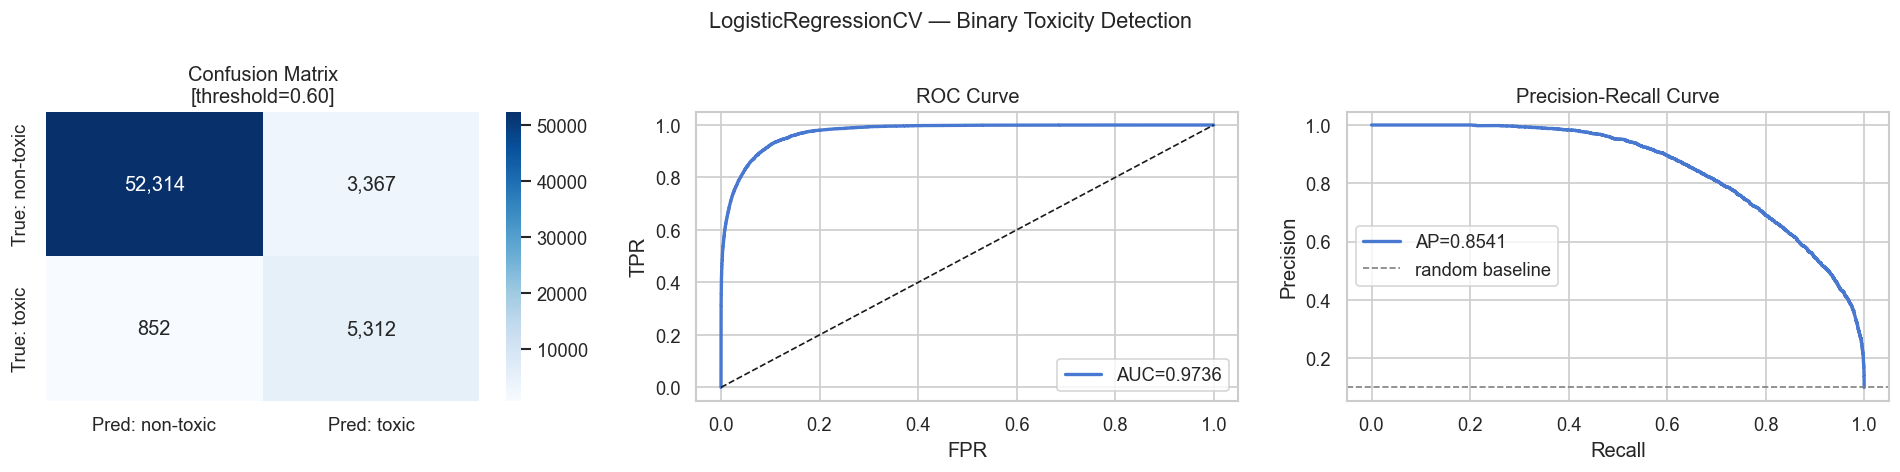

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: non-toxic', 'Pred: toxic'],
            yticklabels=['True: non-toxic', 'True: toxic'])
axes[0].set_title(f'Confusion Matrix\n[threshold={best_t:.2f}]')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC={auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)
axes[2].plot(rec, prec, lw=2, label=f'AP={ap:.4f}')
axes[2].axhline(y_test.mean(), color='grey', ls='--', lw=1, label='random baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.suptitle(f'{best_model_name} — Binary Toxicity Detection', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Interpretability

Even if the best model was SVC or NB, we fit a LogisticRegression with the best sampler for coefficient inspection — LR coefficients are the most interpretable.

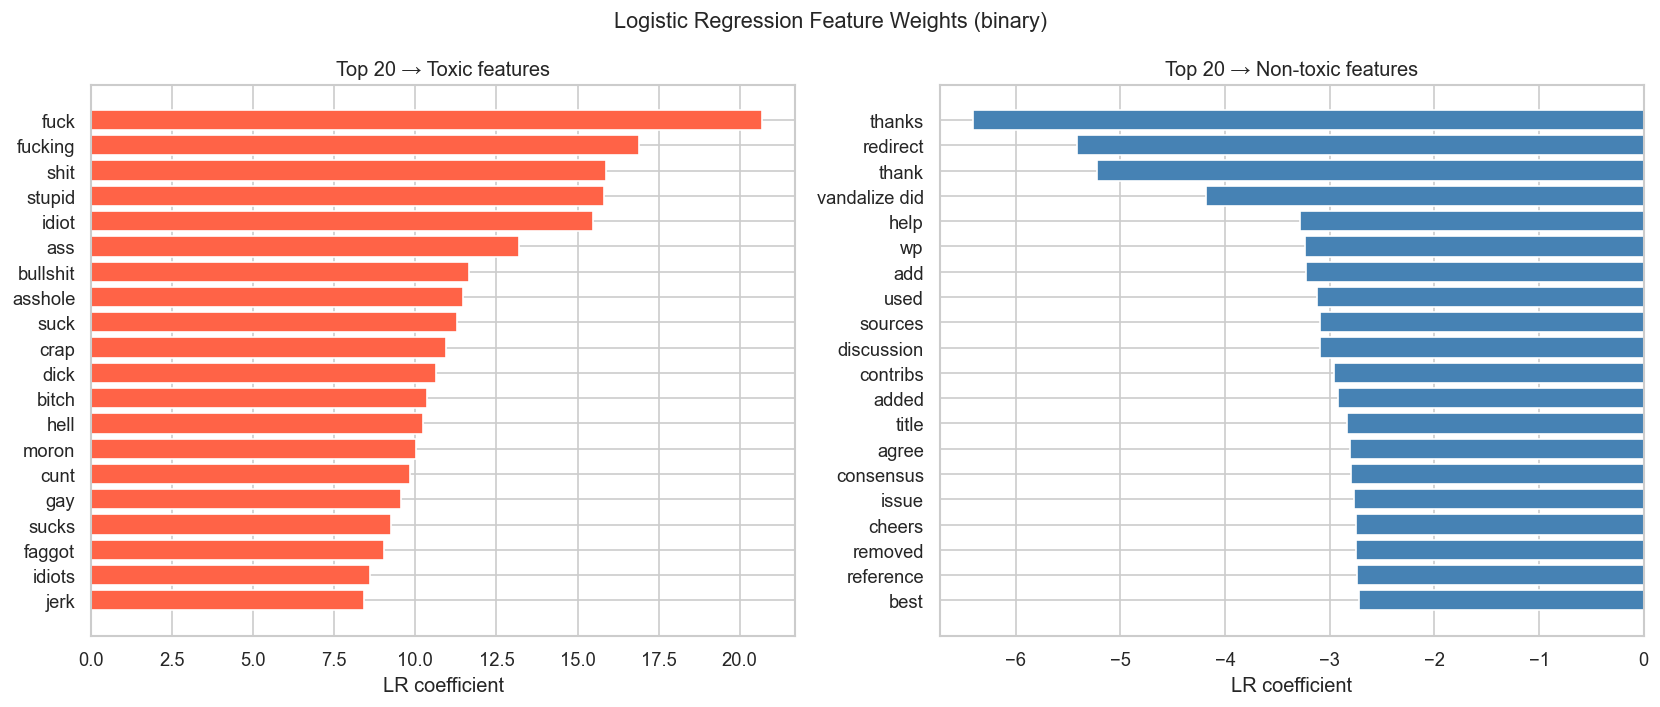

In [ ]:
# Fit a LR with best sampler just for feature weight inspection
lr_for_interp = LogisticRegression(
    C=1.0, class_weight='balanced', solver='liblinear',
    max_iter=1000, random_state=rs,
)
interp_pipe = (
    ImbPipeline([('sampler', best_sampler), ('clf', lr_for_interp)])
    if best_sampler is not None
    else Pipeline([('clf', lr_for_interp)])
)
interp_pipe.fit(X_train, y_train)

feat_names = np.array(_word_tfidf.get_feature_names_out())

coef = interp_pipe.named_steps['clf'].coef_[0]
top_n = 20
top_toxic    = np.argsort(coef)[-top_n:][::-1]
top_nontoxic = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title, color in [
    (axes[0], top_toxic,    f'Top {top_n} → Toxic features',     'tomato'),
    (axes[1], top_nontoxic, f'Top {top_n} → Non-toxic features', 'steelblue'),
]:
    ax.barh(feat_names[idx][::-1], coef[idx][::-1], color=color)
    ax.set_xlabel('LR coefficient')
    ax.set_title(title)
plt.suptitle('Logistic Regression Feature Weights (binary)', fontsize=13)
plt.tight_layout()
plt.show()